In [1]:
# these were discussed in lecture
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
%config InlineBackend.figure_format='retina'
from scipy.interpolate import interp1d
import io
from scipy.integrate import simpson

In [ ]:

# file_path = '/Users/jiamuh/Cloudy23/strong_LOC_N25_m1_blr.ems'

# # Read the file to get all lines
# with open(file_path, 'r') as file:
#     lines = file.readlines()

# # Extract the header from the first row of the file
# header = lines[0].strip().split('\t')

# # Identify the indices of lines containing "GRID_DELIMIT"
# grid_delimit_lines = [i for i, line in enumerate(lines) if "GRID_DELIMIT" in line]

# # Initialize a list to store the models (sections)
# models = []

# # Add a starting point for slicing
# start_idx = 1  # Start after the header

# # Loop through the indices of GRID_DELIMIT to segment the data
# for end_idx in grid_delimit_lines:
#     # Slice the lines from start_idx to end_idx (excluding the GRID_DELIMIT line)
#     section_lines = lines[start_idx:end_idx]
#     if section_lines:  # Ensure there are lines to process
#         section_data = pd.read_csv(
#             io.StringIO("".join(section_lines)),
#             sep="\t",
#             header=None,  # No header in these sections
#             names=header,  # Use the extracted header
#             comment='#'
#         )
#         models.append(section_data)
#     # Update the start index to skip the GRID_DELIMIT line
#     start_idx = end_idx + 1

# # Handle the last section after the final GRID_DELIMIT
# if start_idx < len(lines):
#     section_lines = lines[start_idx:]
#     section_data = pd.read_csv(
#         io.StringIO("".join(section_lines)),
#         sep="\t",
#         header=None,  # No header in these sections
#         names=header,  # Use the extracted header
#         comment='#'
#     )
#     models.append(section_data)

# # Extract arrays for each column across all models
# depth = [model['depth'].values for model in models]
# c4_emissivity = [model['blnd 1549.00A'].values for model in models]
# c3_emissivity = [model['blnd 1909.00A'].values for model in models]
# mg2_emissivity = [model['blnd 2798.00A'].values for model in models]
# si4_emissivity = [model['blnd 1397.00A'].values for model in models]
# o4_emissivity = [model['blnd 1402.00A'].values for model in models]
# n4_emissivity = [model['blnd 1240.00A'].values for model in models]
# hb_emissivity = [model['H  1 4861.32A'].values for model in models]

# # Example: Access data for the first model
# depth_first_model = depth[0]
# c4_emissivity_first_model = c4_emissivity[0]

# print("Depth for first model:", depth_first_model[0])
# print("C4 Emissivity for first model:", c4_emissivity_first_model[0])

# depth_grid = np.array(depth, dtype=object).reshape(9, 7)
# c4_emissivity_grid = np.array(c4_emissivity, dtype=object).reshape(9, 7)
# c3_emissivity_grid = np.array(c3_emissivity, dtype=object).reshape(9, 7)
# mg2_emissivity_grid = np.array(mg2_emissivity, dtype=object).reshape(9, 7)
# si4_emissivity_grid = np.array(si4_emissivity, dtype=object).reshape(9, 7)
# o4_emissivity_grid = np.array(o4_emissivity, dtype=object).reshape(9, 7)
# n4_emissivity_grid = np.array(n4_emissivity, dtype=object).reshape(9, 7)
# hb_emissivity_grid = np.array(hb_emissivity, dtype=object).reshape(9, 7)


# # Define a common depth grid in log space
# log_common_depth = np.logspace(
#     np.log10(min(np.min(arr) for row in depth_grid for arr in row)),
#     np.log10(max(np.max(arr) for row in depth_grid for arr in row)),
#     500  # Choose the number of points for interpolation
# )

# def interpolate_log_grid(depth_grid, emissivity_grid):
#     interpolated_emissivity = []
#     for row_depth, row_emissivity in zip(depth_grid, emissivity_grid):
#         row_interp = []
#         for d, e in zip(row_depth, row_emissivity):
#             # Perform interpolation in log space
#             interp_func = interp1d(
#                 np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf  # Log of 0 is -inf
#             )
#             log_emissivity = 10**interp_func(np.log10(log_common_depth))  # Convert back to linear space
#             row_interp.append(log_emissivity)
#         interpolated_emissivity.append(np.array(row_interp))
#     return interpolated_emissivity

# def integrate_line_luminosity(depth_log, emissivity_grid, gamma, R_in=None, R_out=None):
#     """
#     Integrates the line luminosity over the depth direction in log space.
    
#     Parameters:
#     - depth_log (array): Logarithmic depth values (e.g., log10(depth)).
#     - emissivity_grid (list of arrays): Collapsed emissivity for each row.
#     - R_in (float): Optional lower integration bound in linear space.
#     - R_out (float): Optional upper integration bound in linear space.
    
#     Returns:
#     - L_line (array): Integrated line luminosities for each row.
#     """
#     # Convert log depth to linear space for integration bounds
#     depth_linear = 10**depth_log  # depth_log is assumed to be log10(depth)
    
#     # Define integration bounds
#     if R_in is None:
#         R_in = np.min(depth_linear)
#     if R_out is None:
#         R_out = np.max(depth_linear)
    
#     # Filter depth and emissivity to the integration range
#     valid = (depth_linear >= R_in) & (depth_linear <= R_out)
#     depth_log_filtered = depth_log[valid]
#     depth_linear_filtered = depth_linear[valid]
    
#     # Perform integration for each row in the emissivity grid
#     L_line = []
#     for emissivity in emissivity_grid:
#         emissivity_filtered = np.array(emissivity)[valid]
#         # Calculate r^(3+gamma) * F(r)
#         r_term = depth_linear_filtered**(3 + gamma)
#         integrand = r_term * emissivity_filtered  # r^(3+gamma) * F(r)
        
#         # Integrate over log depth (logarithmic space)
#         L = simpson(integrand, depth_log_filtered)  # Use log(depth) as x
#         L_line.append(L)
    
#     return np.array(L_line)


# # Interpolating depth and emissivity grids in log space
# c4_emissivity_interp = interpolate_log_grid(depth_grid, c4_emissivity_grid)
# mg2_emissivity_interp = interpolate_log_grid(depth_grid, mg2_emissivity_grid)
# hb_emissivity_interp = interpolate_log_grid(depth_grid, hb_emissivity_grid)
# c3_emissivity_interp = interpolate_log_grid(depth_grid, c3_emissivity_grid)
# si4_emissivity_interp = interpolate_log_grid(depth_grid, si4_emissivity_grid)
# o4_emissivity_interp = interpolate_log_grid(depth_grid, o4_emissivity_grid)
# n4_emissivity_interp = interpolate_log_grid(depth_grid, n4_emissivity_grid)


# # Collapse the second dimension by summing
# c4_emissivity_collapsed = [np.sum(row, axis=0) for row in c4_emissivity_interp]
# mg2_emissivity_collapsed = [np.sum(row, axis=0) for row in mg2_emissivity_interp]
# hb_emissivity_collapsed = [np.sum(row, axis=0) for row in hb_emissivity_interp]
# c3_emissivity_collapsed = [np.sum(row, axis=0) for row in c3_emissivity_interp]
# si4_emissivity_collapsed = [np.sum(row, axis=0) for row in si4_emissivity_interp]
# o4_emissivity_collapsed = [np.sum(row, axis=0) for row in o4_emissivity_interp]
# n4_emissivity_collapsed = [np.sum(row, axis=0) for row in n4_emissivity_interp]



# plt.rc('text', usetex=True)
# plt.rc('axes', linewidth=2)
# plt.rc('font', family='serif', size=25)

# phi = np.arange(17,21.5,0.5)
# n = np.arange(9,12.5,0.5)

# rin = 8
# rout = 16

# depth_log = np.linspace(rin, rout, 500)

# # Call the function
# gamma = [-1.4, -0.5] # Korista & Goad (2000), f(r) ~ r^gamma

# log_line_c4 = []
# log_line_mg2 = []
# log_line_hb = []
# log_line_c3 = []
# log_line_si4 = []
# log_line_o4 = []
# log_line_n4 = []

# shift = [23, 11]
# for i, ig in enumerate(gamma):
#         L_line_c4 = integrate_line_luminosity(depth_log, c4_emissivity_collapsed, ig)
#         L_line_mg2 = integrate_line_luminosity(depth_log, mg2_emissivity_collapsed, ig)
#         L_line_hb = integrate_line_luminosity(depth_log, hb_emissivity_collapsed, ig)
#         L_line_c3 = integrate_line_luminosity(depth_log, c3_emissivity_collapsed, ig)
#         L_line_si4 = integrate_line_luminosity(depth_log, si4_emissivity_collapsed, ig)
#         L_line_o4 = integrate_line_luminosity(depth_log, o4_emissivity_collapsed, ig)
#         L_line_n4 = integrate_line_luminosity(depth_log, n4_emissivity_collapsed, ig)

#         log_line_c4.append(np.log10(L_line_c4) + shift[i])
#         log_line_mg2.append(np.log10(L_line_mg2) + shift[i])
#         log_line_hb.append(np.log10(L_line_hb) + shift[i])
#         log_line_c3.append(np.log10(L_line_c3) + shift[i])
#         log_line_si4.append(np.log10(L_line_si4) + shift[i])
#         log_line_o4.append(np.log10(L_line_o4) + shift[i])
#         log_line_n4.append(np.log10(L_line_n4) + shift[i])


# # Example data (replace these with your real calculations)
# phi = np.arange(17, 21.5, 0.5)

# # Create figure and axes
# fig, ax1 = plt.subplots(figsize=(8, 6))

# # Define a color palette for consistent coloring
# colors = {
#     'CIV': 'blue',
#     'MgII': 'orange',
#     r'H$\beta$': 'green',
#     'CIII]': 'red',
#     'SiIV': 'purple',
#     'OIV]': 'brown',
#     'NV': 'pink'
# }

# # Plot the first set of lines with solid styles
# ax1.plot(phi, log_line_c4[0], label='CIV', color=colors['CIV'], lw=3)
# ax1.plot(phi, log_line_mg2[0], label='MgII', color=colors['MgII'], lw=3)
# ax1.plot(phi, log_line_hb[0], label=r'H$\beta$', color=colors[r'H$\beta$'], lw=3)
# ax1.plot(phi, log_line_c3[0], label='CIII]', color=colors['CIII]'], lw=3)
# ax1.plot(phi, log_line_si4[0], label='SiIV', color=colors['SiIV'], lw=3)
# ax1.plot(phi, log_line_o4[0], label='OIV]', color=colors['OIV]'], lw=3)
# ax1.plot(phi, log_line_n4[0], label='NV', color=colors['NV'], lw=3)

# # Label primary x-axis and y-axis
# ax1.set_xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
# ax1.set_ylabel("Line Luminosity [erg/s]")

# # Add twin x-axis
# ax2 = ax1.twiny()
# ax2.set_xlim([lim + 25.5 for lim in ax1.get_xlim()])
# ax2.set_xlabel(r'$\log L_{\rm 3000}~\rm [erg/s]$', labelpad=10)

# # Add legend
# ax1.legend(ncol=2, fontsize=16, loc='lower right')

# # Customize ticks
# ax1.tick_params(axis='y', which='major', length=6, width=1.5, direction='in', top=True, right=True)
# ax1.tick_params(axis='y', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
# ax1.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
# ax1.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
# ax2.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
# ax2.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)

# # Save plot
# plt.savefig('line_luminosity.png')
# plt.show()



data = np.loadtxt('/Users/jiamuh/python/clq_properties/022740.16-004157.9_mgc4.txt', skiprows=1)
log_l3000 = data[:, 0]
mg2_c4 = data[:, 1]
mg2_c4_err = data[:, 3]

data1 = np.loadtxt('/Users/jiamuh/python/clq_properties/023259.60+004801.7_mgc4.txt', skiprows=1)
log_l3000_1 = data1[:, 0]
mg2_c4_1 = data1[:, 1]
mg2_c4_err_1 = data1[:, 3]

data2 = np.loadtxt('/Users/jiamuh/python/clq_properties/141218.03+541817.1_mgc4.txt', skiprows=1)
log_l3000_2 = data2[:, 0]
mg2_c4_2 = data2[:, 1]
mg2_c4_err_2 = data2[:, 3]

data3 = np.loadtxt(''/Users/jiamuh/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Sep_6/sdss_rm_plots/rm_line_ratio/rm560_mg2_c4_ratios.txt'', skiprows=1)
log_l3000_3 = np.log10(data3[:, 0]) + 37.5
mg2_c4_3 = data3[:, 1]
mg2_c4_err_3 = data3[:, 2]

data4 = np.loadtxt('/Users/jiamuh/Desktop/Desktop_Sep_6/rm658_mg2_c4_ratios.txt', skiprows=1)
log_l3000_4 = np.log10(data4[:, 0]) + 37
mg2_c4_4 = data4[:, 1]
mg2_c4_err_4 = data4[:, 2]

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot data
ax1.plot(phi, 10**(log_line_mg2[0] - log_line_c4[0]), label=r'$\Gamma = -1.4$', lw=3, c='k')
ax1.plot(phi, 10**(log_line_mg2[1] - log_line_c4[1]), label=r'$\Gamma = -0.5$', lw=3, c='k', linestyle='--')

ax1.errorbar(log_l3000 - 25.5, mg2_c4, yerr=mg2_c4_err, fmt='o', color='C0', label='Observed', capsize=5)
ax1.errorbar(log_l3000_1 - 25.5, mg2_c4_1, yerr=mg2_c4_err_1, fmt='o', color='C1', capsize=5)
ax1.errorbar(log_l3000_2 - 25.5, mg2_c4_2, yerr=mg2_c4_err_2, fmt='o', color='C2', capsize=5)
ax1.errorbar(log_l3000_3, mg2_c4_3, yerr=mg2_c4_err_3, fmt='o', color='C3', capsize=5)
ax1.errorbar(log_l3000_4, mg2_c4_4, yerr=mg2_c4_err_4, fmt='o', color='C4', capsize=5)

# Label primary x-axis and y-axis
ax1.set_xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
ax1.set_ylabel("MgII/CIV")
#ax1.set_xlim([19, 21])
ax1.set_ylim([0.01, 2.5])
# Add twin x-axis
ax2 = ax1.twiny()
ax2.set_xlim([lim + 25.5 for lim in ax1.get_xlim()])
ax2.set_xlabel(r'$\log L_{\rm 3000}~\rm [erg/s]$', labelpad=10)

# Add legend
ax1.legend(ncol=2, fontsize=16, loc='upper left')

# Customize ticks
ax1.tick_params(axis='y', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='y', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
ax2.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax2.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)


# Save plot
plt.savefig('line_ratio_mgc4.png')
plt.show()

#plt.savefig('line_luminosity.png')

FileNotFoundError: /Users/jiamuh/Desktop/Desktop_Sep_6/rm560_mg2_c4_ratios.txt not found.

In [ ]:
/Users/jiamuh/python/clq_properties/023259.60+004801.7_mgc4.txt

In [66]:
# # Function to process each file
# def process_file(file_path):
#     with open(file_path, 'r') as file:
#         lines = file.readlines()

#     # Extract header
#     header = lines[0].strip().split('\t')

#     # Find GRID_DELIMIT indices
#     grid_delimit_lines = [i for i, line in enumerate(lines) if "GRID_DELIMIT" in line]

#     # Parse sections into models
#     models = []
#     start_idx = 1
#     for end_idx in grid_delimit_lines:
#         section_lines = lines[start_idx:end_idx]
#         if section_lines:
#             section_data = pd.read_csv(
#                 io.StringIO("".join(section_lines)),
#                 sep="\t",
#                 header=None,
#                 names=header,
#                 comment='#'
#             )
#             models.append(section_data)
#         start_idx = end_idx + 1
#     if start_idx < len(lines):
#         section_lines = lines[start_idx:]
#         section_data = pd.read_csv(
#             io.StringIO("".join(section_lines)),
#             sep="\t",
#             header=None,
#             names=header,
#             comment='#'
#         )
#         models.append(section_data)

#     # Extract arrays for columns
#     depth = [model['depth'].values for model in models]
#     c4_emissivity = [model['blnd 1549.00A'].values for model in models]
#     mg2_emissivity = [model['blnd 2798.00A'].values for model in models]
    
#     return depth, c4_emissivity, mg2_emissivity

# # Function to interpolate log grids
# def interpolate_log_grid(depth_grid, emissivity_grid, log_common_depth):
#     interpolated_emissivity = []
#     for row_depth, row_emissivity in zip(depth_grid, emissivity_grid):
#         row_interp = []
#         for d, e in zip(row_depth, row_emissivity):
#             interp_func = interp1d(
#                 np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf
#             )
#             log_emissivity = 10**interp_func(np.log10(log_common_depth))
#             row_interp.append(log_emissivity)
#         interpolated_emissivity.append(np.array(row_interp))
#     return interpolated_emissivity

# # Function to integrate luminosity
# def integrate_line_luminosity(depth_log, emissivity_grid, gamma, R_in=None, R_out=None):
#     depth_linear = 10**depth_log
#     if R_in is None:
#         R_in = np.min(depth_linear)
#     if R_out is None:
#         R_out = np.max(depth_linear)
#     valid = (depth_linear >= R_in) & (depth_linear <= R_out)
#     depth_log_filtered = depth_log[valid]
#     depth_linear_filtered = depth_linear[valid]
#     L_line = []
#     for emissivity in emissivity_grid:
#         emissivity_filtered = np.array(emissivity)[valid]
#         r_term = depth_linear_filtered**(3 + gamma)
#         integrand = r_term * emissivity_filtered
#         L = simpson(integrand, depth_log_filtered)
#         L_line.append(L)
#     return np.array(L_line)

/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)


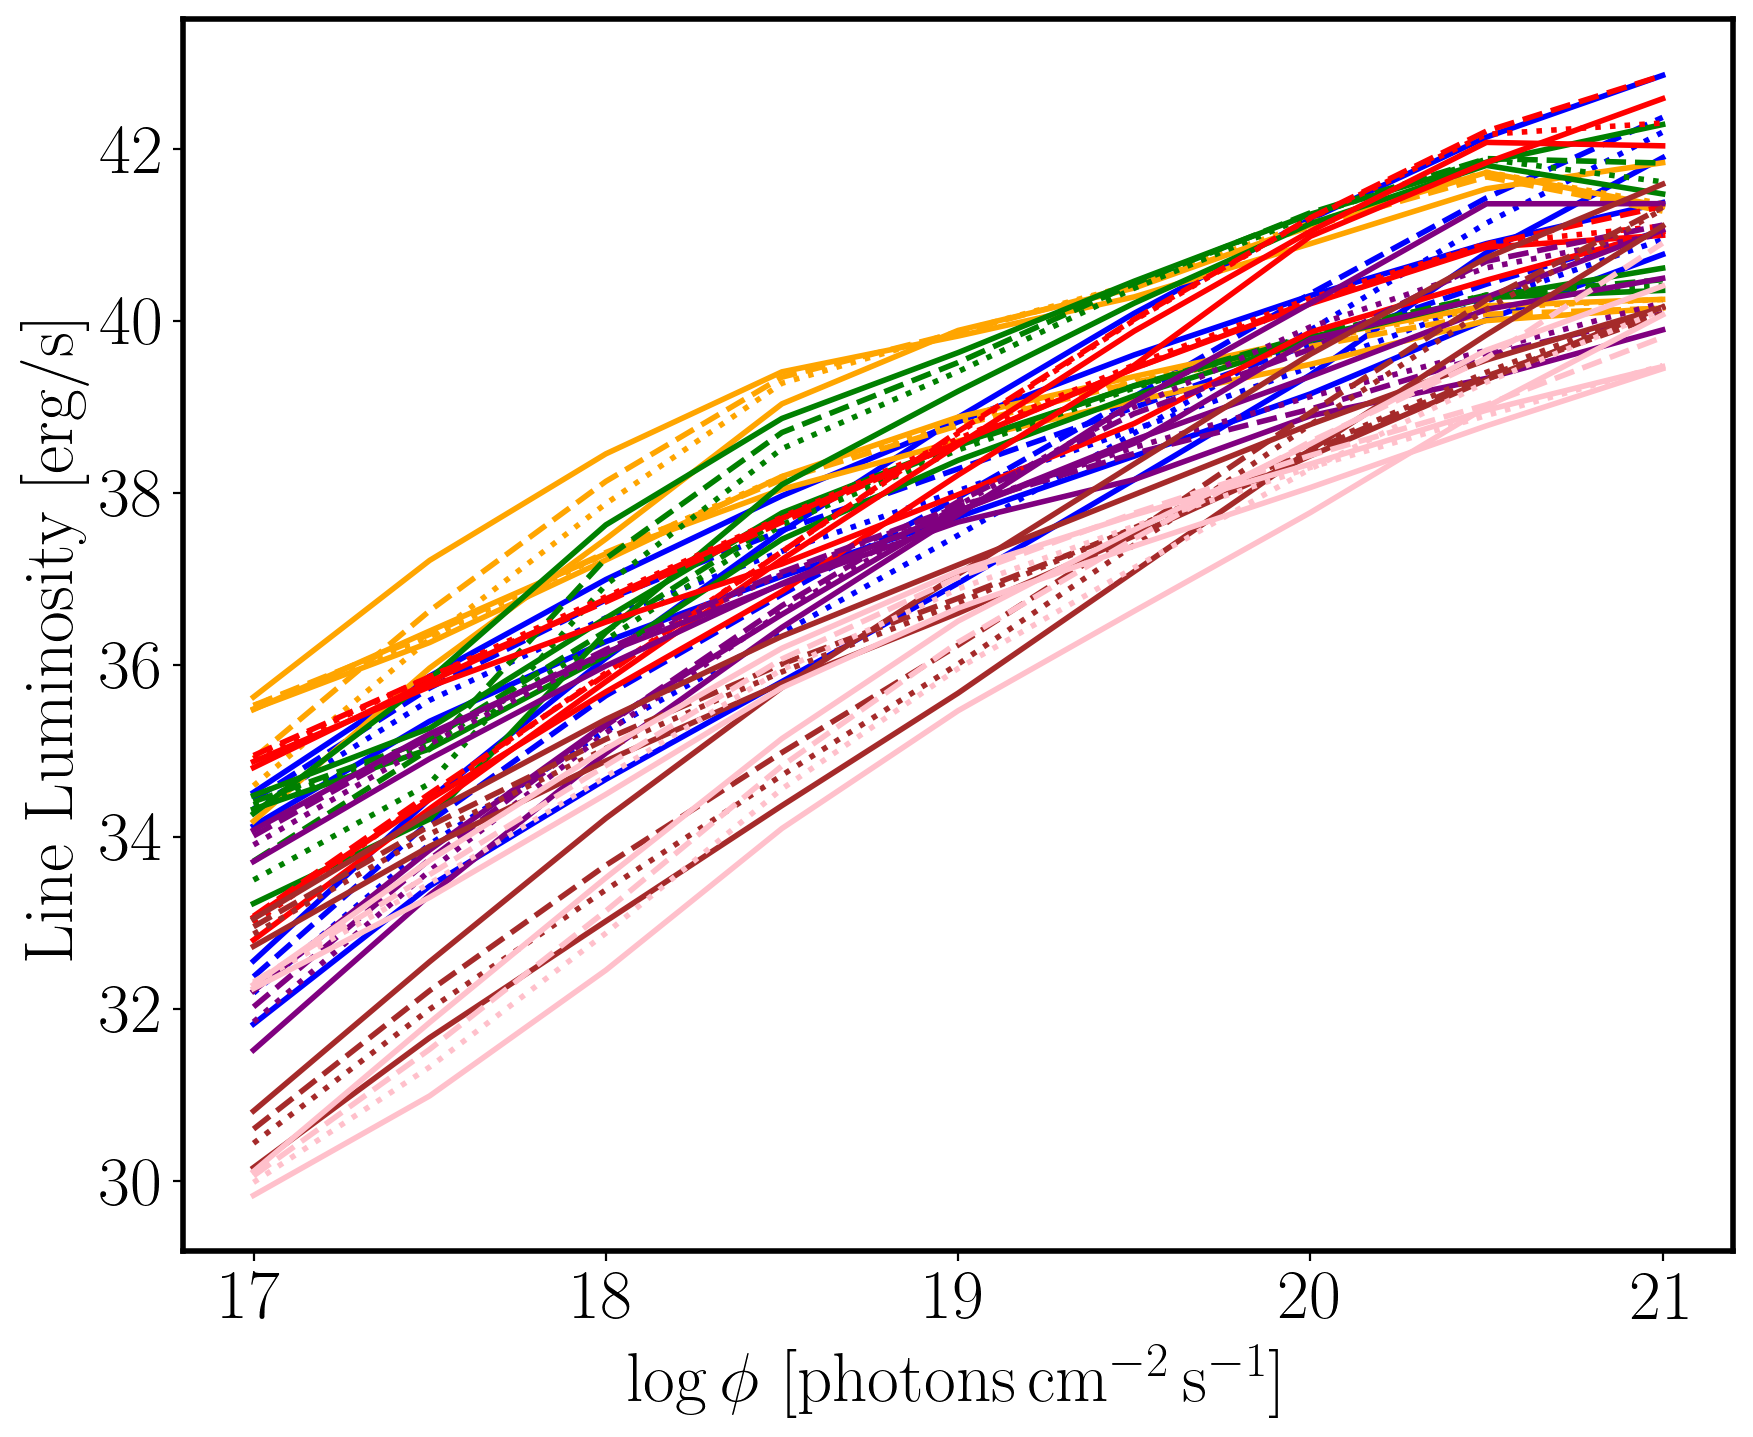

In [67]:
# File paths and labels
file_paths = [
    '/Users/huangjiamu/Cloudy23/strong_LOC_N25_m1_blr.ems',
    '/Users/huangjiamu/Cloudy23/strong_LOC_N25_m3_blr.ems',
    '/Users/huangjiamu/Cloudy23/strong_LOC_N25_m5_blr.ems',
    '/Users/huangjiamu/Cloudy23/strong_LOC_N25_m10_blr.ems'
]
file_labels = [r'$Z=Z_{\odot}$', r'$Z=3Z_{\odot}$', r'$Z=5Z_{\odot}$', r'$Z=10Z_{\odot}$']

# Initialize storage
all_log_lines = {'CIV': [], 'MgII': [], r'H$\beta$': [], 'CIII]': [], 'SiIV': [], 'OIV]': [], 'NV': []}

# Function to process a file and return emissivity grids
def process_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    header = lines[0].strip().split('\t')
    grid_delimit_lines = [i for i, line in enumerate(lines) if "GRID_DELIMIT" in line]
    models = []
    start_idx = 1
    for end_idx in grid_delimit_lines:
        section_lines = lines[start_idx:end_idx]
        if section_lines:
            section_data = pd.read_csv(
                io.StringIO("".join(section_lines)),
                sep="\t",
                header=None,
                names=header,
                comment='#'
            )
            models.append(section_data)
        start_idx = end_idx + 1
    if start_idx < len(lines):
        section_lines = lines[start_idx:]
        section_data = pd.read_csv(
            io.StringIO("".join(section_lines)),
            sep="\t",
            header=None,
            names=header,
            comment='#'
        )
        models.append(section_data)

    # Extract arrays for each column
    depth = [model['depth'].values for model in models]
    emissivities = {
        'CIV': [model['blnd 1549.00A'].values for model in models],
        'MgII': [model['blnd 2798.00A'].values for model in models],
        r'H$\beta$': [model['H  1 4861.32A'].values for model in models],
        'CIII]': [model['blnd 1909.00A'].values for model in models],
        'SiIV': [model['blnd 1397.00A'].values for model in models],
        'OIV]': [model['blnd 1402.00A'].values for model in models],
        'NV': [model['blnd 1240.00A'].values for model in models],
    }
    return depth, emissivities

# Function to interpolate data
def interpolate_log_grid(depth_grid, emissivity_grid, log_common_depth):
    interpolated_emissivity = []
    for row_depth, row_emissivity in zip(depth_grid, emissivity_grid):
        row_interp = []
        for d, e in zip(row_depth, row_emissivity):
            interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
            log_emissivity = 10**interp_func(np.log10(log_common_depth))
            row_interp.append(log_emissivity)
        interpolated_emissivity.append(np.array(row_interp))
    return interpolated_emissivity

# Function to integrate line luminosity
def integrate_line_luminosity(depth_log, emissivity_grid, gamma):
    depth_linear = 10**depth_log
    L_line = []
    for emissivity in emissivity_grid:
        integrand = depth_linear**(3 + gamma) * emissivity
        L = simpson(integrand, depth_log)
        L_line.append(L)
    return np.array(L_line)

# Process each file
for file_path, label in zip(file_paths, file_labels):
    depth, emissivities = process_file(file_path)
    depth_grid = np.array(depth, dtype=object).reshape(9, 7)

    log_common_depth = np.logspace(
        np.log10(min(np.min(arr) for row in depth_grid for arr in row)),
        np.log10(max(np.max(arr) for row in depth_grid for arr in row)),
        500
    )
    depth_log = np.log10(log_common_depth)
    gamma = [-1.4, -0.5]
    shift = [23, 11]

    log_lines = {key: [] for key in emissivities.keys()}
    for i, ig in enumerate(gamma):
        for line, emissivity in emissivities.items():
            emissivity_grid = np.array(emissivity, dtype=object).reshape(9, 7)
            emissivity_interp = interpolate_log_grid(depth_grid, emissivity_grid, log_common_depth)
            emissivity_collapsed = [np.sum(row, axis=0) for row in emissivity_interp]
            L_line = integrate_line_luminosity(depth_log, emissivity_collapsed, ig)
            log_lines[line].append(np.log10(L_line) + shift[i])

    for line, log_line in log_lines.items():
        all_log_lines[line].append(log_line)

# Plotting parameters
phi = np.arange(17, 21.5, 0.5)
linestyles = ['solid', 'dashed', 'dotted']
colors = {'CIV': 'blue', 'MgII': 'orange', r'H$\beta$': 'green', 'CIII]': 'red', 'SiIV': 'purple', 'OIV]': 'brown', 'NV': 'pink'}

# # Plot Line Luminosity
# plt.figure(figsize=(10, 8))
# for line, color in colors.items():
#     for idx, log_line in enumerate(all_log_lines[line]):
#         plt.plot(phi, log_line[0], label=f'{file_labels[idx]} ({line})', linestyle=linestyles[idx], lw=2, color=color)



# Plot Line Luminosity
plt.figure(figsize=(10, 8))
for line, color in colors.items():
    for idx, log_lines_for_file in enumerate(all_log_lines[line]):
        for i, log_line in enumerate(log_lines_for_file):  # Handle nested structure
            plt.plot(phi, log_line, label=f'{file_labels[idx]} ({line}, γ={gamma[i]})',
                     linestyle=linestyles[idx % len(linestyles)], lw=2, color=color)

plt.xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
plt.ylabel("Line Luminosity [erg/s]")
#plt.legend(ncol=2, fontsize=10, loc='lower right')
#plt.savefig('combined_line_luminosity.png')
plt.show()


In [68]:
mg2_c4_ratios = []
for idx, log_line in enumerate(all_log_lines['MgII']):
    mg2 = 10**np.array(log_line)  # Convert log(MgII) to linear scale
    civ = 10**np.array(all_log_lines['CIV'][idx])  # Convert log(CIV) to linear scale
    mg2_c4_ratios.append((mg2 / civ).tolist())  # Store the ratio


/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/2360568257.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = get_cmap("cool")


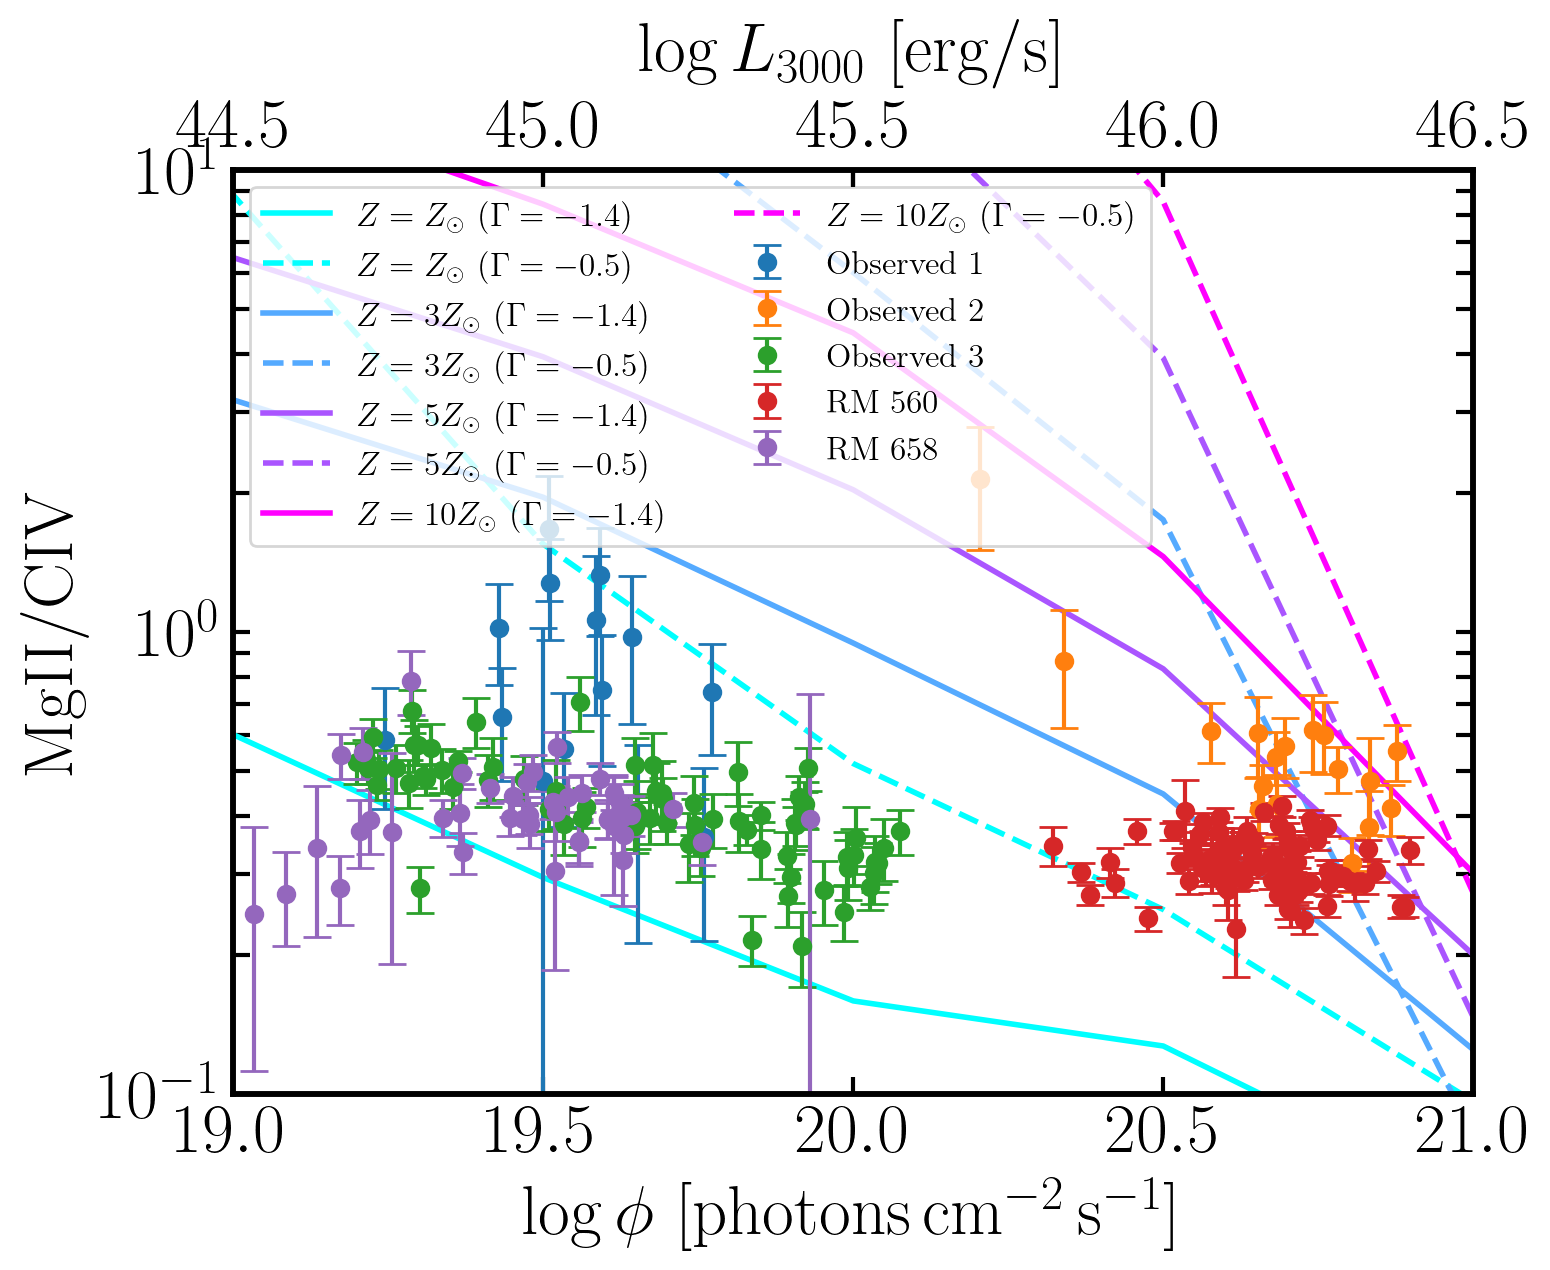

In [69]:
from matplotlib.cm import get_cmap

# Use the "cool" colormap
colormap = get_cmap("cool")

# Generate gradient colors for the models
gradient_colors = colormap(np.linspace(0, 1, len(file_paths)))

# Create plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot MgII/CIV ratios for models
linestyles = ['solid', 'dashed']  # Solid for Gamma = -1.4, dashed for Gamma = -0.5
for idx, (ratio_gamma_minus_1_4, ratio_gamma_minus_0_5) in enumerate(mg2_c4_ratios):
    # Plot Gamma = -1.4
    ax1.plot(phi, ratio_gamma_minus_1_4, label=f'{file_labels[idx]} ($\Gamma = -1.4$)', 
             lw=2, linestyle=linestyles[0], color=gradient_colors[idx])
    # Plot Gamma = -0.5
    ax1.plot(phi, ratio_gamma_minus_0_5, label=f'{file_labels[idx]} ($\Gamma = -0.5$)', 
             lw=2, linestyle=linestyles[1], color=gradient_colors[idx])

# Plot observational data
ax1.errorbar(log_l3000 - 25.5, mg2_c4, yerr=mg2_c4_err, fmt='o', color='C0', label='Observed 1', capsize=5)
ax1.errorbar(log_l3000_1 - 25.5, mg2_c4_1, yerr=mg2_c4_err_1, fmt='o', color='C1', label='Observed 2', capsize=5)
ax1.errorbar(log_l3000_2 - 25.5, mg2_c4_2, yerr=mg2_c4_err_2, fmt='o', color='C2', label='Observed 3', capsize=5)
ax1.errorbar(log_l3000_3, mg2_c4_3, yerr=mg2_c4_err_3, fmt='o', color='C3', label='RM 560', capsize=5)
ax1.errorbar(log_l3000_4, mg2_c4_4, yerr=mg2_c4_err_4, fmt='o', color='C4', label='RM 658', capsize=5)

# Label primary x-axis and y-axis
ax1.set_xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
ax1.set_ylabel("MgII/CIV")
ax1.set_xlim([19, 21])
ax1.set_ylim([0.01, 5.5])

# Add twin x-axis for luminosity
ax2 = ax1.twiny()
ax2.set_xlim([lim + 25.5 for lim in ax1.get_xlim()])
ax2.set_xlabel(r'$\log L_{\rm 3000}~\rm [erg/s]$', labelpad=10)
ax2.set_yscale('log')
ax2.set_ylim([1e-1, 1e1])
# Add legend
ax1.legend(ncol=2, fontsize=12, loc='upper left')

# Customize ticks
ax1.tick_params(axis='y', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='y', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax1.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)
ax2.tick_params(axis='x', which='major', length=6, width=1.5, direction='in', top=True, right=True)
ax2.tick_params(axis='x', which='minor', length=6, width=1.5, direction='in', top=True, right=True)

# Save and show plot
plt.savefig('combined_line_ratio_cool_colormap.png')
plt.show()


In [13]:
import numpy as np

def load_quasar_fluxes_grouped(filename):
    quasar_data = {}
    data_started = False

    with open(filename, 'r') as f:
        for line in f:
            if not data_started:
                if line.strip().startswith("CT"):
                    data_started = True
                else:
                    continue
            if not line.strip():
                continue

            fields = line.strip().split()
            quasar = fields[0]

            # field names in same order
            field_names = [
                'JD_Lya', 'Lya', 'e_Lya',
                'JD_SiIV', 'SiIV', 'e_SiIV',
                'JD_CIV', 'CIV', 'e_CIV',
                'JD_CIII', 'CIII', 'e_CIII',
                'JD_MgII', 'MgII', 'e_MgII',
                'JD_Rband', 'Rband', 'e_Rband'
            ]

            # Parse only valid float fields
            values = []
            for i in range(1, min(len(fields), 19)):
                try:
                    val = float(fields[i])
                except ValueError:
                    continue
                values.append((field_names[i - 1], val))

            # Initialize if first time
            if quasar not in quasar_data:
                quasar_data[quasar] = {k: [] for k in field_names}

            for k, v in values:
                quasar_data[quasar][k].append(v)

    # Convert to numpy arrays
    for quasar in quasar_data:
        for k in quasar_data[quasar]:
            quasar_data[quasar][k] = np.array(quasar_data[quasar][k])

    return quasar_data


In [43]:
import pandas as pd
import numpy as np

def load_quasar_fluxes_grouped(filename):
    colspecs = [
        (0, 7), (8, 14), (15, 20), (21, 25),
        (26, 32), (33, 37), (38, 42),
        (43, 49), (50, 54), (55, 59),
        (60, 66), (67, 71), (72, 76),
        (77, 83), (84, 88), (89, 93),
        (94, 100), (101, 105), (106, 111)
    ]

    names = [
        'Quasar',
        'JD_Lya', 'Lya', 'e_Lya',
        'JD_SiIV', 'SiIV', 'e_SiIV',
        'JD_CIV', 'CIV', 'e_CIV',
        'JD_CIII', 'CIII', 'e_CIII',
        'JD_MgII', 'MgII', 'e_MgII',
        'JD_Rband', 'Rband', 'e_Rband'
    ]

    # Detect first line of data (starts with 'CT')
    with open(filename, 'r') as f:
        lines = f.readlines()
    start = next(i for i, line in enumerate(lines) if line.strip().startswith("CT"))

    # Load only data lines
    df = pd.read_fwf(
        filename,
        colspecs=colspecs,
        names=names,
        skiprows=start,
        na_values='------'
    )

    quasar_dict = {}
    for quasar, group in df.groupby('Quasar'):
        group = group.drop(columns='Quasar')
        quasar_dict[quasar] = {
            col: group[col].dropna().astype(float).to_numpy()
            for col in group.columns if not group[col].dropna().empty
        }

    return quasar_dict





flux_dict = load_quasar_fluxes_grouped("/Users/jiamuh/Desktop/apjaada45t5_mrt.txt")

Rdata = flux_dict['CT1061']['Rband'][0:len(flux_dict['CT1061']['CIV'])]



Text(0, 0.5, 'Line Ratio')

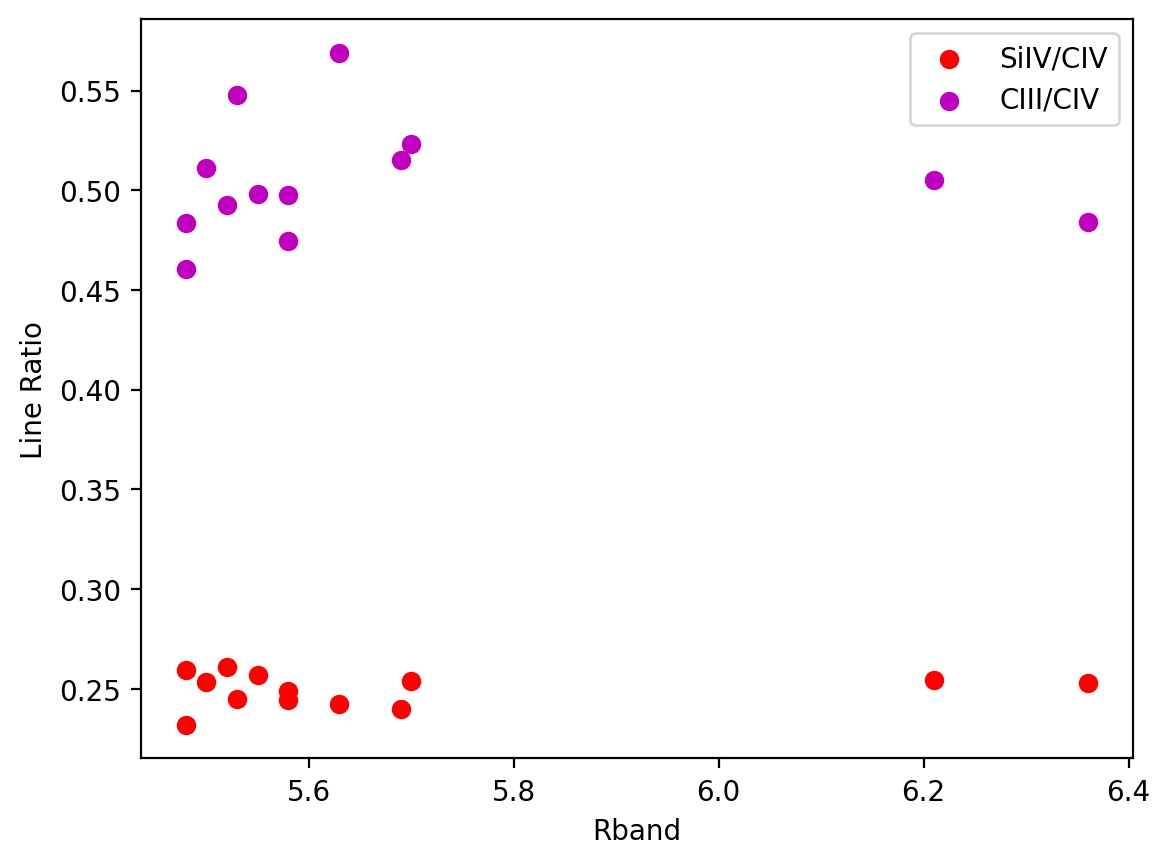

In [46]:
plt.scatter(Rdata, flux_dict['CT1061']['SiIV']/flux_dict['CT1061']['CIV'], c='r', label='SiIV/CIV')
plt.scatter(Rdata, flux_dict['CT1061']['CIII']/flux_dict['CT1061']['CIV'], c='m', label='CIII/CIV')
plt.legend()
plt.xlabel('Rband')
plt.ylabel('Line Ratio')
#plt.scatter(flux_dict['CT1061']['JD_Lya'][0:len(flux_dict['CT1061']['CIV'])], flux_dict['CT1061']['Lya'], c='c', label='Lya')


/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)
/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)


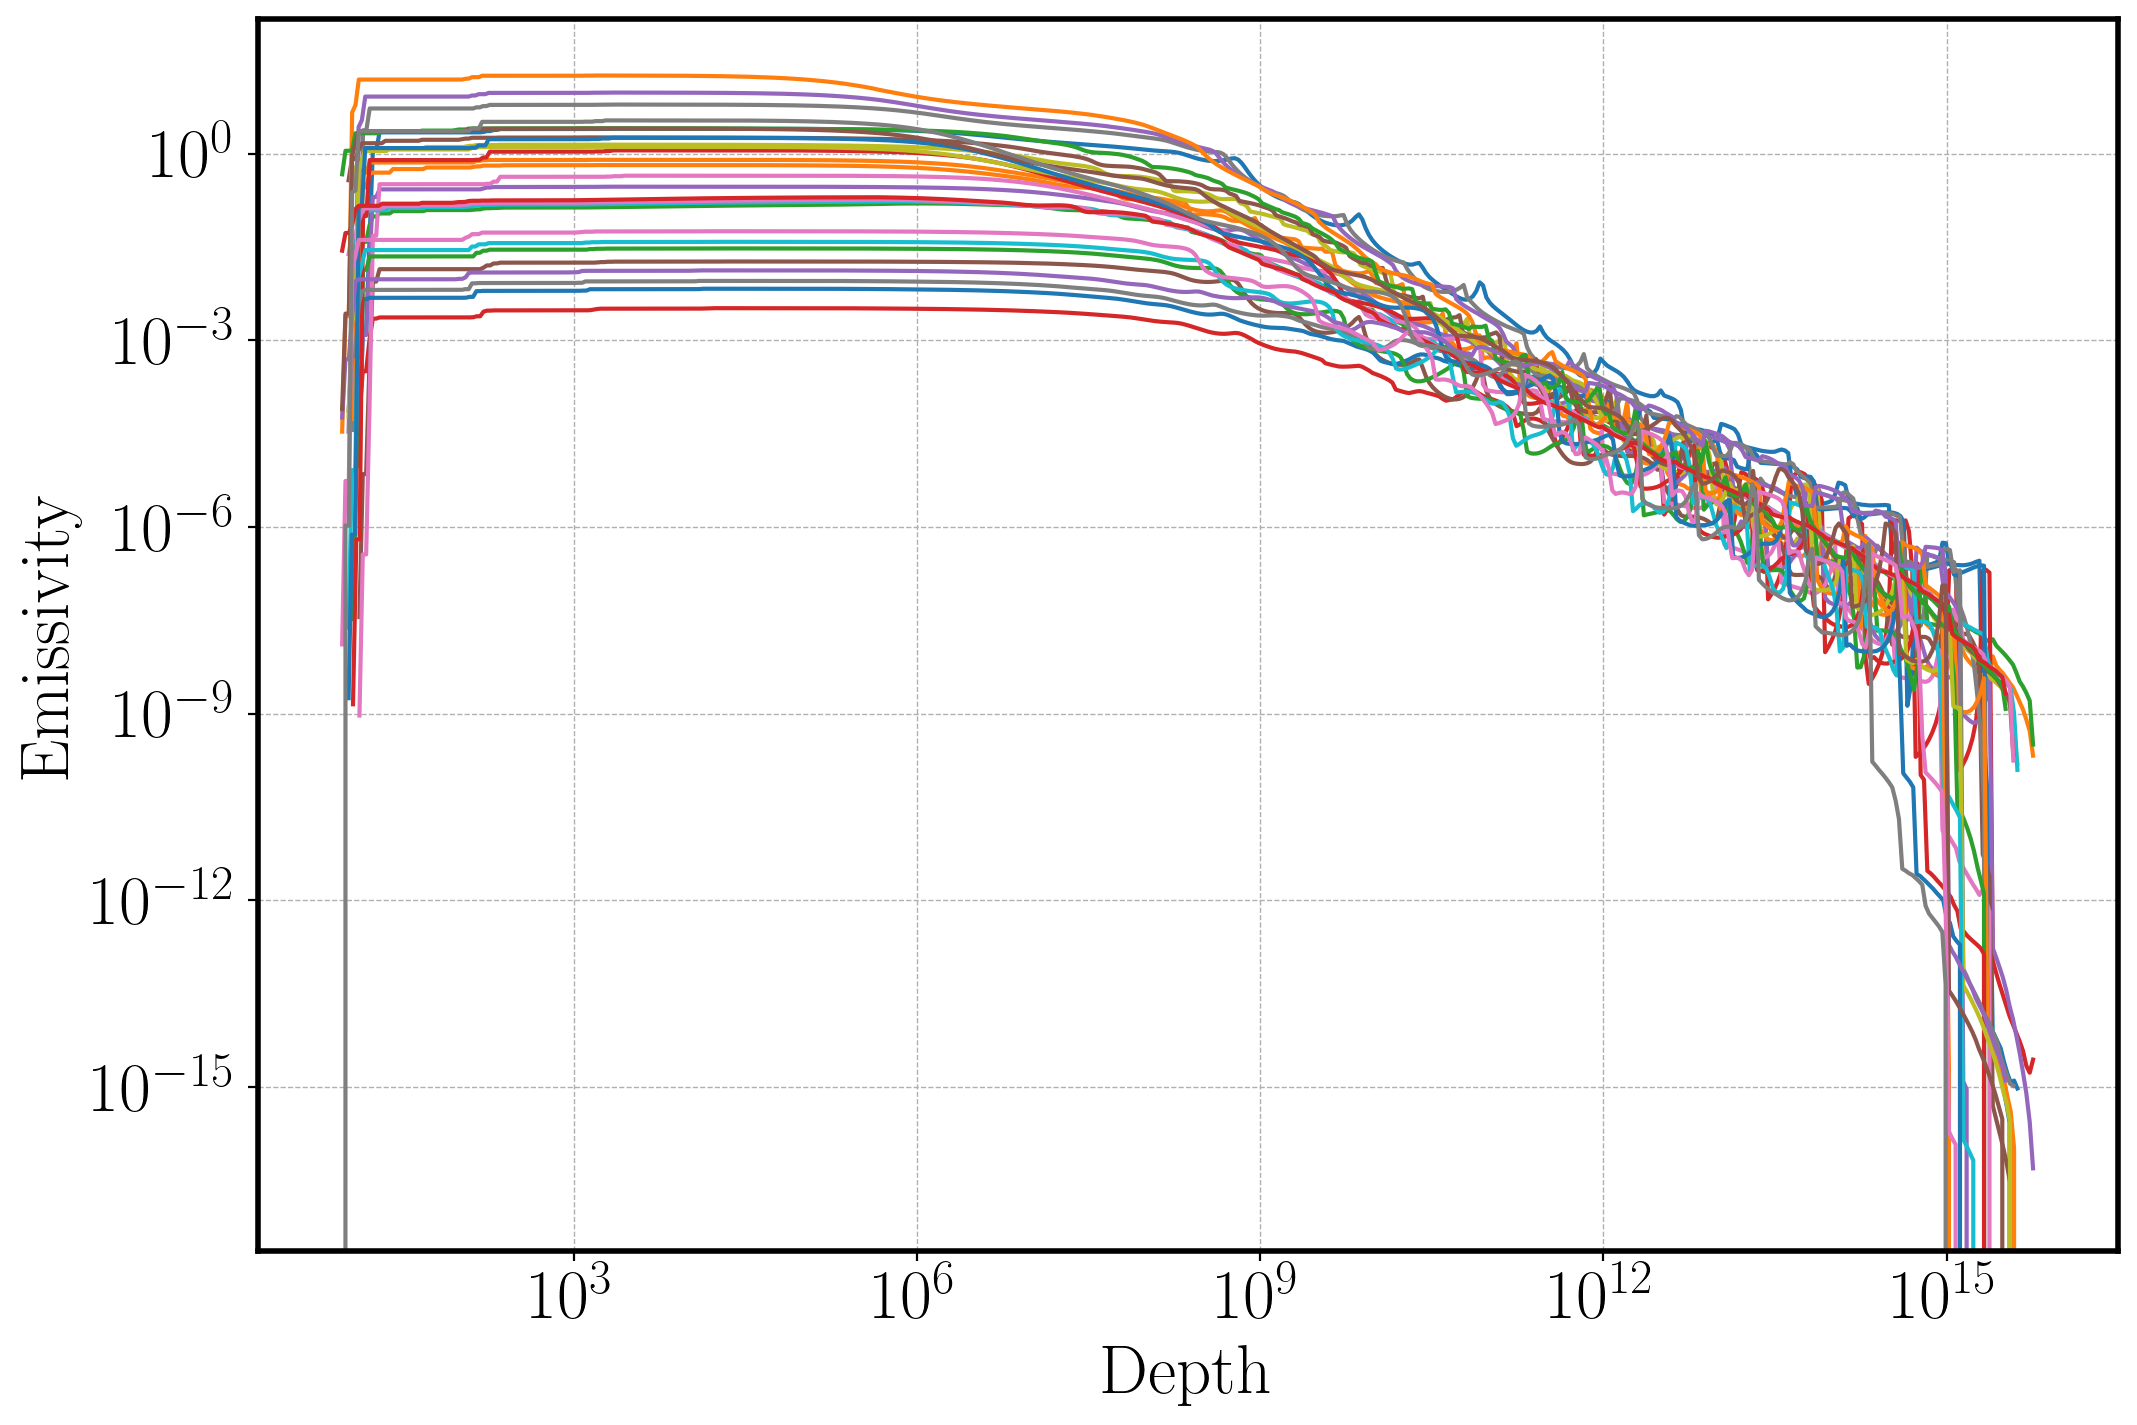

In [70]:
# Plot Emissivity as a Function of Common Depth Grid
plt.figure(figsize=(12, 8))

for file_path, label in zip(file_paths, file_labels):
    depth, emissivities = process_file(file_path)
    depth_grid = np.array(depth, dtype=object).reshape(9, 7)

    log_common_depth = np.logspace(
        np.log10(min(np.min(arr) for row in depth_grid for arr in row)),
        np.log10(max(np.max(arr) for row in depth_grid for arr in row)),
        500
    )
    depth_log = np.log10(log_common_depth)

    for line, emissivity in emissivities.items():
        emissivity_grid = np.array(emissivity, dtype=object).reshape(9, 7)
        emissivity_interp = interpolate_log_grid(depth_grid, emissivity_grid, log_common_depth)

        # Collapse the interpolated emissivity by summing over the grid
        emissivity_collapsed = [np.sum(row, axis=0) for row in emissivity_interp]

        # Average over all rows for simplicity in plotting
        emissivity_avg = np.mean(emissivity_collapsed, axis=0)

        # Plot the average emissivity against the common depth grid
        plt.plot(log_common_depth, emissivity_avg, label=f'{label} ({line})')

# Add plot labels and legend
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Depth')
plt.ylabel('Emissivity')
#plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


In [32]:
def metallicity_profile(r):
    """
    Define metallicity as a function of radius.
    """
    if r < 1e7:
        return 0  # Index for Z=Z_\odot
    elif r < 1e10:
        return 1  # Index for Z=3Z_\odot
    elif r < 1e12:
        return 2  # Index for Z=5Z_\odot
    else:
        return 3  # Index for Z=10Z_\odot
    

/var/folders/br/6sw3kv492t7c0z79vwnhb9gr0000gn/T/ipykernel_12595/3675638185.py:64: RuntimeWarning: divide by zero encountered in log10
  interp_func = interp1d(np.log10(d), np.log10(e), bounds_error=False, fill_value=-np.inf)


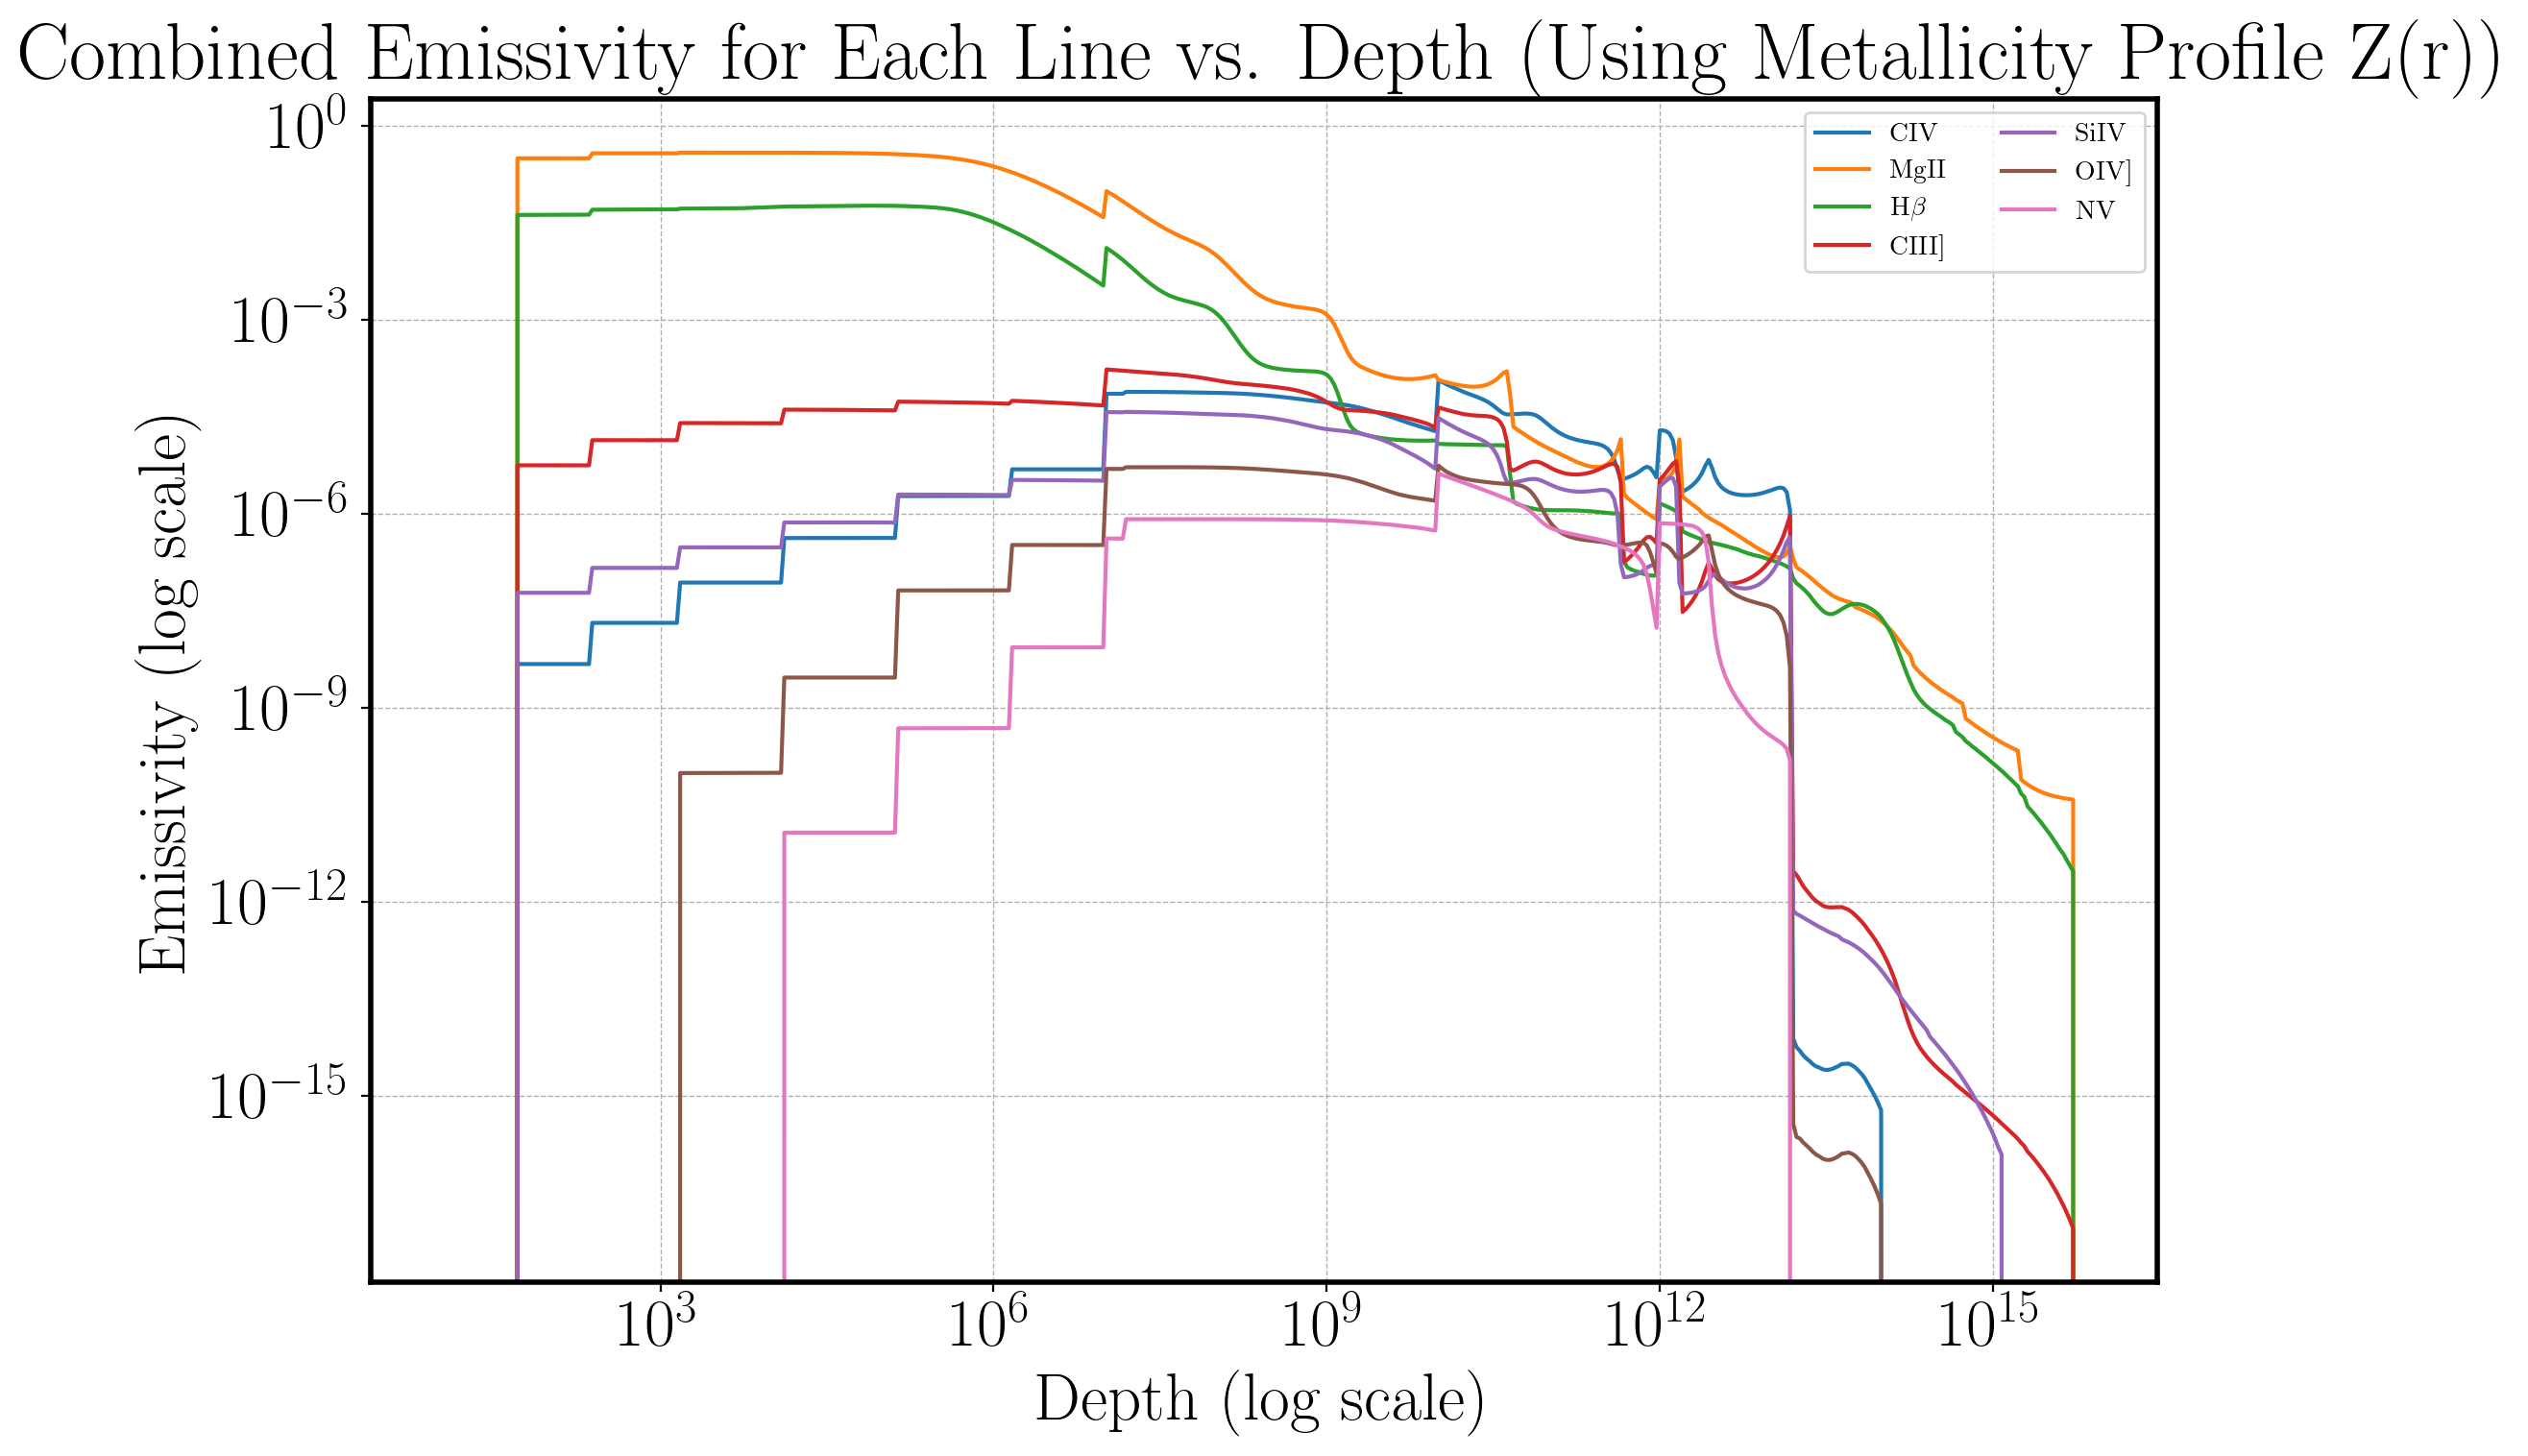

In [36]:
def combine_emissivity_by_line(depth_grid, emissivities, log_common_depth, metallicity_profile):
    """
    Combine emissivity values for each line based on the metallicity profile.
    """
    combined_emissivity_by_line = {line: np.zeros_like(log_common_depth) for line in emissivities.keys()}

    for line, emissivity in emissivities.items():
        emissivity_grid = np.array(emissivity, dtype=object).reshape(9, 7)
        emissivity_interp = interpolate_log_grid(depth_grid, emissivity_grid, log_common_depth)

        for i, depth in enumerate(log_common_depth):
            metallicity_idx = metallicity_profile(depth)  # Determine metallicity index

            # Select the interpolated emissivity for the metallicity index
            if 0 <= metallicity_idx < len(emissivity_interp):
                emissivity_for_metallicity = emissivity_interp[metallicity_idx]

                # Sum over rows for this depth to reduce the array to a scalar
                scalar_emissivity = np.sum(emissivity_for_metallicity[:, i]) if emissivity_for_metallicity.ndim > 1 else emissivity_for_metallicity[i]

                # Add the scalar emissivity for this depth
                combined_emissivity_by_line[line][i] += scalar_emissivity

    return combined_emissivity_by_line


# Plot the Combined Emissivity for Each Line
plt.figure(figsize=(12, 8))

depth, emissivities = process_file(file_paths[0])  # Process one file (as Z is combined)
depth_grid = np.array(depth, dtype=object).reshape(9, 7)

log_common_depth = np.logspace(
    np.log10(min(np.min(arr) for row in depth_grid for arr in row)),
    np.log10(max(np.max(arr) for row in depth_grid for arr in row)),
    500
)

# Combine emissivity based on the metallicity profile
combined_emissivity_by_line = combine_emissivity_by_line(depth_grid, emissivities, log_common_depth, metallicity_profile)

# Plot for each line
for line, combined_emissivity in combined_emissivity_by_line.items():
    plt.plot(
        log_common_depth,
        combined_emissivity,
        label=f'{line}',  # No Z labels, as Z(r) is already applied
    )

# Add plot labels and legend
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Depth (log scale)')
plt.ylabel('Emissivity (log scale)')
plt.legend(fontsize=10, ncol=2)
plt.title('Combined Emissivity for Each Line vs. Depth (Using Metallicity Profile Z(r))')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


In [ ]:
# Compute Combined Emissivity and Line Intensities
phi = np.arange(17, 21.5, 0.5)  # Define phi range
gamma = -1.4  # Use single gamma
shift = 23  # Shift for gamma
colors = {'CIV': 'blue', 'MgII': 'orange', r'H$\beta$': 'green', 'CIII]': 'red', 'SiIV': 'purple', 'OIV]': 'brown', 'NV': 'pink'}

# Initialize storage
combined_intensities = {key: [] for key in emissivities.keys()}
ratios = {'MgII/CIV': []}

# Compute combined emissivity grid based on Z(r)
for line, emissivity in emissivities.items():
    emissivity_grid = np.array(emissivity, dtype=object).reshape(9, 7)  # Reshape to grid
    combined_emissivity_grid = []

    for i in range(emissivity_grid.shape[0]):  # Loop over phi grid
        row_combined = []
        for j in range(emissivity_grid.shape[1]):  # Loop over metallicity
            metallicity_idx = metallicity_profile(j)  # Determine metallicity based on profile
            row_combined.append(emissivity_grid[i][metallicity_idx])
        combined_emissivity_grid.append(np.sum(row_combined, axis=0))  # Sum over metallicity rows

    # Store combined emissivity grid for line
    combined_intensities[line] = combined_emissivity_grid

# Compute line luminosities and ratios
line_intensities = {line: [] for line in combined_intensities.keys()}

for line, combined_emissivity_grid in combined_intensities.items():
    for combined_emissivity in combined_emissivity_grid:
        # Compute line luminosity
        L_line = integrate_line_luminosity(depth_log, [combined_emissivity], gamma)
        log_L_line = np.log10(L_line.flatten()) + shift  # Ensure flattening
        line_intensities[line].append(log_L_line)

# Compute MgII/CIV ratio
ratios['MgII/CIV'] = [
    10**(line_intensities['MgII'][i] - line_intensities['CIV'][i])
    for i in range(len(line_intensities['MgII']))
]

# Plot Line Intensities
plt.figure(figsize=(10, 8))
for line, color in colors.items():
    plt.plot(phi, line_intensities[line], label=f'{line}', color=color)

plt.xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
plt.ylabel(r'$\log L_{\rm line}~\rm [erg/s]$')
plt.legend(ncol=2, fontsize=10, loc='upper left')
plt.title("Line Luminosities as a Function of $\phi$")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.savefig('line_luminosities_vs_phi_respecting_Zr.png')
plt.show()

# Plot Ratios
plt.figure(figsize=(10, 8))
plt.plot(phi, ratios['MgII/CIV'], label='MgII/CIV', color='black')

plt.xlabel(r'$\log \phi$ $[\rm photons\,cm^{-2}\,s^{-1}]$')
plt.ylabel('MgII/CIV Ratio')
plt.xscale('linear')
plt.yscale('log')
plt.legend(fontsize=10, loc='upper left')
plt.title("MgII/CIV Ratio as a Function of $\phi$")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
#plt.savefig('mgii_civ_ratio_vs_phi_respecting_Zr.png')
plt.show()


ValueError: operands could not be broadcast together with shapes (500,) (271,) 

In [41]:
len(phi)

9

In [40]:
ratios['MgII/CIV']

array([1.34796723])